<a href="https://colab.research.google.com/github/alexpanayi474/DSC511-MovieLens-Project/blob/main/DSC_511_MovieLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# give access to google colab to have access to your google drive, in order to be able to read the datasets
from google.colab import drive
drive.mount('/content/gdrive')
google_drive_path = "/content/gdrive/MyDrive/Colab Notebooks/Data/DSC_511_PROJECT/"

Mounted at /content/gdrive


In [3]:

#  Spark Core
from pyspark.sql import SparkSession, Row
from pyspark.sql.functions import *
from pyspark.sql.types import *

# EDA / Visualization (Pandas + Plotting)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  ML: Feature Engineering
from pyspark.ml import Pipeline
from pyspark.ml.feature import *

#  ML: Regression Models
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor

#  ML: Evaluation
from pyspark.ml.evaluation import RegressionEvaluator

#  ML: Hyperparameter Tuning
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

#  Recommendation System (ALS)
from pyspark.ml.recommendation import ALS


# create a spark session
spark = SparkSession.builder.appName("DSC_511_PROJECT").master("local[*]") .getOrCreate()

In [4]:
# 2. Data Ingestion
# Load the MovieLens CSV files into Spark DataFrames.
# Spark infers the schema automatically (inferSchema=True),
# mapping columns to their appropriate types (int, double, string).
ratings_df = spark.read.csv(google_drive_path + 'ratings.csv', header=True, inferSchema=True)
ratings_df.printSchema()

movies_df = spark.read.csv(google_drive_path + 'movies.csv', header=True, inferSchema=True)
movies_df.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



In [5]:
# ── Persist DataFrames in memory
ratings_df.persist()
movies_df.persist()

DataFrame[movieId: int, title: string, genres: string]

In [6]:
ratings_df.count() #rows in ratings_df

33832162

In [7]:
movies_df.count() #rows in movies_df

86537

In [8]:
#overview of the data
ratings_df.show(5)
movies_df.show(5)

+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|      1|   4.0|1225734739|
|     1|    110|   4.0|1225865086|
|     1|    158|   4.0|1225733503|
|     1|    260|   4.5|1225735204|
|     1|    356|   5.0|1225735119|
+------+-------+------+----------+
only showing top 5 rows
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


In [9]:
#checking for NAs
from pyspark.sql.functions import col, sum as spark_sum, count
print("NULLs in ratings_df")
ratings_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in ratings_df.columns]).show()

print("NULLs in movies_df")
movies_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in movies_df.columns]).show()

NULLs in ratings_df
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

NULLs in movies_df
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+



In [10]:
# checking for duplicates
print("Duplicates in ratings_df:", ratings_df.count() - ratings_df.dropDuplicates().count())
print("Duplicates in movies_df:", movies_df.count() - movies_df.dropDuplicates().count())

Duplicates in ratings_df: 0
Duplicates in movies_df: 0


In [11]:
#from pyspark.sql.functions import col, from_unixtime, to_timestamp
# converting Unix timestamp to readable datetime format
ratings_clean = ratings_df.withColumn("ts", to_timestamp(from_unixtime(col("timestamp"))))

In [12]:
# merging the dataframes
movies_ratings_merged = ratings_clean.join(movies_df, on="movieId", how="inner")
movies_ratings_merged.select("userId","movieId","rating","ts","title","genres").show(5, truncate=False)

+------+-------+------+-------------------+-----------------------------------------+-------------------------------------------+
|userId|movieId|rating|ts                 |title                                    |genres                                     |
+------+-------+------+-------------------+-----------------------------------------+-------------------------------------------+
|1     |1      |4.0   |2008-11-03 17:52:19|Toy Story (1995)                         |Adventure|Animation|Children|Comedy|Fantasy|
|1     |110    |4.0   |2008-11-05 06:04:46|Braveheart (1995)                        |Action|Drama|War                           |
|1     |158    |4.0   |2008-11-03 17:31:43|Casper (1995)                            |Adventure|Children                         |
|1     |260    |4.5   |2008-11-03 18:00:04|Star Wars: Episode IV - A New Hope (1977)|Action|Adventure|Sci-Fi                    |
|1     |356    |5.0   |2008-11-03 17:58:39|Forrest Gump (1994)                      |Comed

In [13]:
#  Find the actual date range of ratings in the dataset
ratings_clean.select(min("ts").alias("oldest_rating"),max("ts").alias("newest_rating")).show(truncate=False)

+-------------------+-------------------+
|oldest_rating      |newest_rating      |
+-------------------+-------------------+
|1995-01-09 11:46:44|2023-07-20 08:53:33|
+-------------------+-------------------+



In [14]:
# basic statistics for the rating column
movies_ratings_merged.select("rating").describe().show()

+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|          33832162|
|   mean|  3.54254040873888|
| stddev|1.0639586178664766|
|    min|               0.5|
|    max|               5.0|
+-------+------------------+



In [15]:
# unique users, movies and total records in the joined dataframe
print("Total ratings:", movies_ratings_merged.count())
print("Unique users:", movies_ratings_merged.select("userId").distinct().count())
print("Unique movies:", movies_ratings_merged.select("movieId").distinct().count())
print("Unique ratings:", movies_ratings_merged.select("rating").distinct().count())
# movies_df contains 86,537 movies but the joined df only has 83,239 unique movies, due to the fact that some movies exist in movies_df but have no ratings in ratings_df.

Total ratings: 33832162
Unique users: 330975
Unique movies: 83239
Unique ratings: 10


In [16]:
# unique number of genres in movies and joined df
print("Unique genres:", movies_ratings_merged.withColumn("genre", explode(split("genres", "\\|"))) \
                                             .select("genre").distinct().count())
print("Unique genres in movies df:", movies_df.withColumn("genre", explode(split("genres", "\\|"))) \
                                              .select("genre").distinct().count())
# 21 in both

Unique genres: 21
Unique genres in movies df: 21


In [17]:
# rating value distribution ,frequency of each rating
movies_ratings_merged.groupBy("rating").count().orderBy("rating").show()

+------+-------+
|rating|  count|
+------+-------+
|   0.5| 566306|
|   1.0|1013645|
|   1.5| 562409|
|   2.0|2146492|
|   2.5|1760733|
|   3.0|6400664|
|   3.5|4465001|
|   4.0|8835955|
|   4.5|3123055|
|   5.0|4957902|
+------+-------+



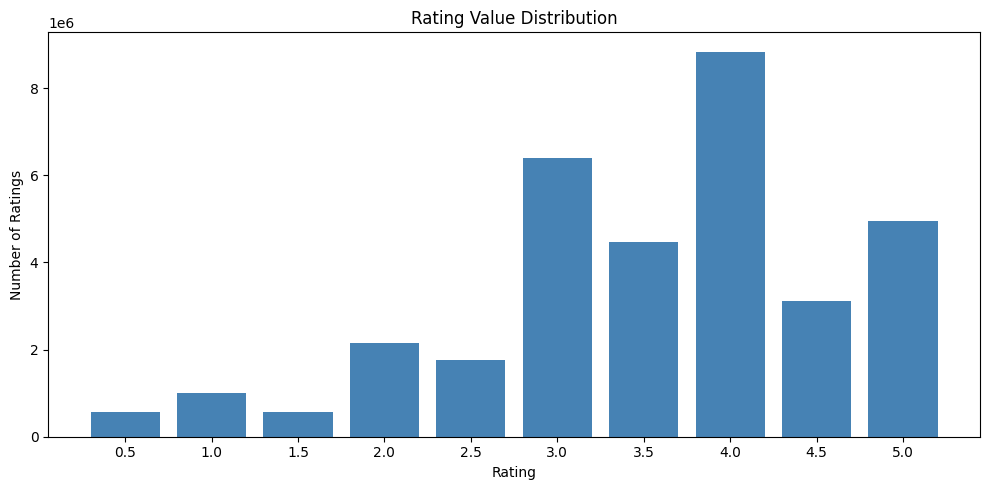

In [18]:
# Rating Distribution
import matplotlib.pyplot as plt
import pandas as pd

# Group by rating value and count occurrences, convert to pandas for plotting
rating_dist = movies_ratings_merged.groupBy("rating") \
                                   .count() \
                                   .orderBy("rating") \
                                   .toPandas()

plt.figure(figsize=(10, 5))
plt.bar(rating_dist["rating"], rating_dist["count"], width=0.4, color="steelblue")
plt.title("Rating Value Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rating_dist["rating"])
plt.tight_layout()
plt.show()
#most common rating is 4 followed by 3

In [19]:
# distinct genres
from pyspark.sql.functions import explode, split, col

movies_df.withColumn("genre", explode(split(col("genres"), "\\|"))).select("genre").distinct().orderBy("genre").show(21)

+--------------------+
|               genre|
+--------------------+
| We're Comin' To ...|
|  (no genres listed)|
|              Action|
|           Adventure|
|           Animation|
|            Children|
|              Comedy|
|               Crime|
|         Documentary|
|               Drama|
|             Fantasy|
|           Film-Noir|
|              Horror|
|                IMAX|
|             Musical|
|             Mystery|
|             Romance|
|              Sci-Fi|
|            Thriller|
|                 War|
|             Western|
+--------------------+



In [20]:
# rows where genres is a title
movies_ratings_merged.filter(col("genres").contains("We're Comin'")).show(5, truncate=False)

+-------+------+------+----------+-------------------+--------------------------------------------------------+----------------------------------+
|movieId|userId|rating|timestamp |ts                 |title                                                   |genres                            |
+-------+------+------+----------+-------------------+--------------------------------------------------------+----------------------------------+
|284105 |314043|2.0   |1677106513|2023-02-22 22:55:13|"The Newbridge Tourism Board Presents: ""We're Newbridge| We're Comin' To Get Ya!"" (2014)"|
+-------+------+------+----------+-------------------+--------------------------------------------------------+----------------------------------+



In [21]:
# removing the row with the genre that is a title
bad_id = movies_df.filter(col("genres").contains("We're Comin'")).select("movieId").first()[0]

print("Corrupted movieId:", bad_id)

# Drop from all 3 dataframes
movies_df             = movies_df.filter(col("movieId") != bad_id)
ratings_df            = ratings_df.filter(col("movieId") != bad_id)
movies_ratings_merged = movies_ratings_merged.filter(col("movieId") != bad_id)


print("movies_df rows:", movies_df.count())
print("ratings_df rows:", ratings_df.count())
print("movies_ratings_merged rows:", movies_ratings_merged.count())

Corrupted movieId: 284105
movies_df rows: 86536
ratings_df rows: 33832161
movies_ratings_merged rows: 33832161


In [22]:
# Distinct userIds
ratings_df.select("userId").distinct().count()

330975

# **EDA**
## EDA Part 1: Movies Released Per Year

We begin by extracting the **release year** from each movie title using a regular expression,
since the year is embedded in the title string (e.g. *"Toy Story (1995)"*).

This analysis is performed on the **full `movies_df`** dataset (86,537 movies), which includes
movies that were never rated on MovieLens. This gives a more accurate picture of movie
production over time, compared to using only the joined DataFrame which would exclude ~3,300
unrated movies.

> **Note:** This chart reflects movies *catalogued on MovieLens*, not the entire global film
> production — so it carries a bias toward popular and English-language films.

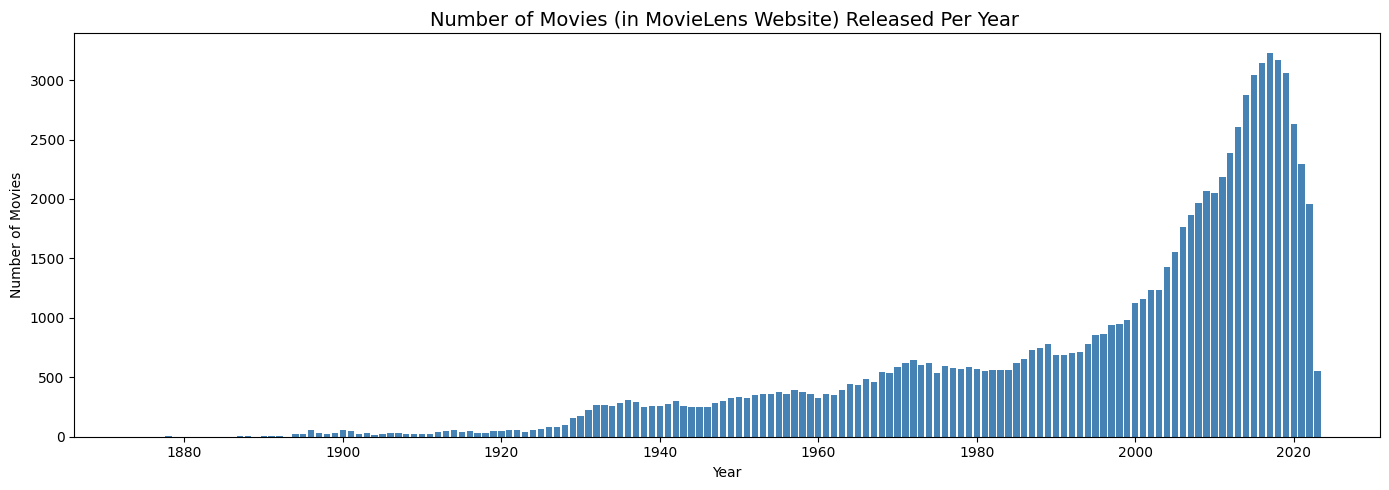

In [23]:
# Extract year from title string using regex, then groupBy year
movies_with_year = movies_df.withColumn("release_year",regexp_extract(col("title"), r"\((\d{4})\)", 1))

movies_per_year = (movies_with_year
    .filter(col("release_year") != "")     # remove empty matches BEFORE casting
    .withColumn("release_year", col("release_year").cast("int")) # regexp_extract always returns a string (e.g. "1995"), .cast() converts a column from one data type to another
    .groupBy("release_year").agg(count("movieId").alias("num_movies")).orderBy("release_year").toPandas()
)

plt.figure(figsize=(14, 5))
plt.bar(movies_per_year["release_year"], movies_per_year["num_movies"], color="steelblue", width=0.8)
plt.title("Number of Movies (in MovieLens Website) Released Per Year ", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

### Observations

- **Pre-1940s**: Very few titles — the film industry was still in its infancy.
- **1940s–1970s**: Slow but steady growth as cinema became a mainstream entertainment medium.
- **1980s–2000s**: Rapid acceleration driven by the **home video revolution** (VHS/DVD),
  which made cataloguing older and new films more viable.
- **Peak around 2015–2018**: The **streaming era** (Netflix, Amazon Prime, Disney+) triggered
  a global surge in film and series production.
- **Drop after 2020**: Attributable to **COVID-19** production shutdowns in 2020–2021,
  combined with the dataset's collection cutoff date.
- **Included but unrated**: The ~3,300 movies present in `movies_df` but absent from
  `ratings_df` are still counted here — they are valid productions simply never reviewed
  by MovieLens users.

## Part 2: MovieLens Platform Popularity Over Time
To understand how the **MovieLens platform grew over time**, we analyze the total number
of ratings submitted by users in each **6-month period** from 1997 (platform launch) to 2023.

We use the `ratings_clean` DataFrame which already has the `ts` column — a proper Spark
timestamp converted from the raw Unix epoch integer in `ratings_df`.

### Why 6-month bins?
Monthly bins would produce ~300 bars (too noisy). Yearly bins would hide seasonal patterns.
6-month bins give a clean balance — enough granularity to see trends without clutter.


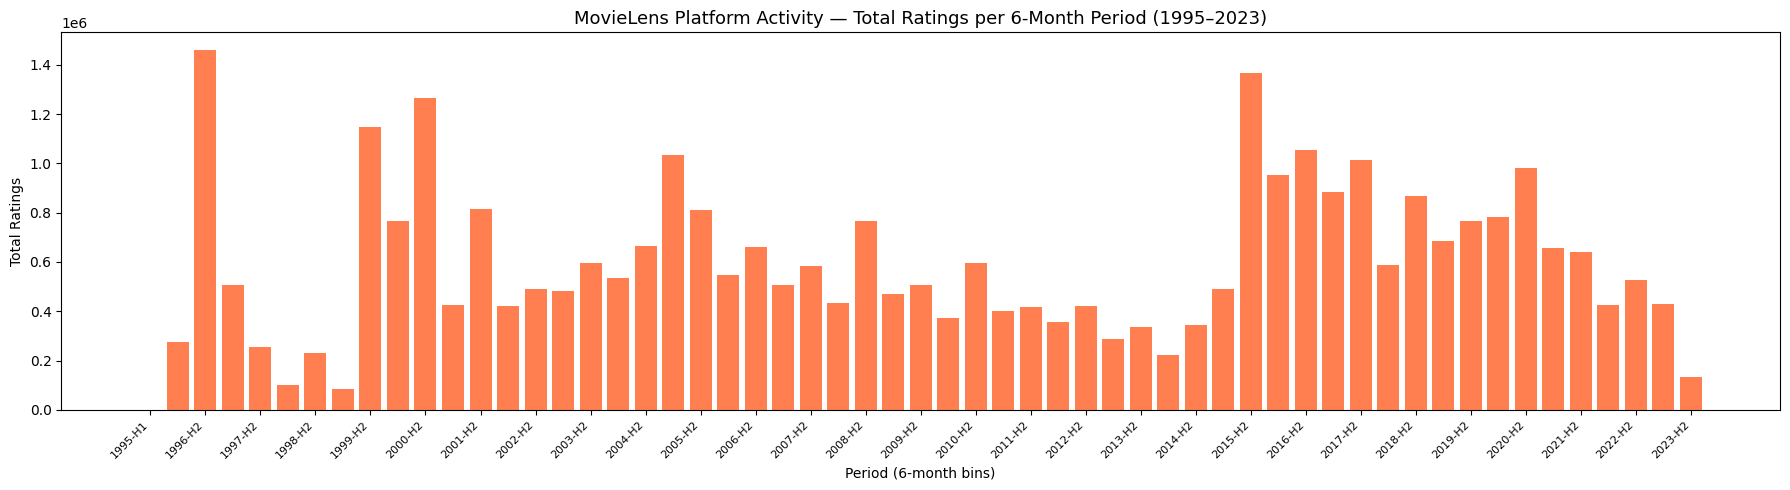

In [24]:
# Count total ratings per 6-month period from 1997 to 2023
# Group by 6-month periods to track platform growth.
from pyspark.sql.functions import year, month, concat_ws, lpad, count, col, when,floor

ratings_timeline = (ratings_clean

    # Step 1: Extract year and month from the timestamp column
    .withColumn("year",  year(col("ts")))
    .withColumn("month", month(col("ts")))

    # floor(month / 6) == 0 → months 1-5 → H1
    # floor(month / 6) != 0 → months 6-12 → H2
    .withColumn("half",
        when(floor(col("month") / 6) == 0, "H1").otherwise("H2")
    )

    # Step 3: Build readable period label e.g. "2005-H1", "2005-H2"
    .withColumn("period_label",
        concat_ws("-", col("year").cast("string"), col("half"))
    )

    # Step 4: Keep only ratings from 1997 (platform launch) to 2023
    #.filter((col("year") >= 1997) & (col("year") <= 2023))

    # Step 5: Group by period and count total ratings in each 6-month bin
    .groupBy("year", "half", "period_label")
    .agg(count("rating").alias("total_ratings"))

    # Step 6: Sort chronologically — H1 before H2 within each year
    .orderBy("year", "half")

    .toPandas()
)

plt.figure(figsize=(18, 5))
plt.bar(range(len(ratings_timeline)), ratings_timeline["total_ratings"], color="coral")
plt.xticks(
    range(0, len(ratings_timeline), 2),       # show every 2nd label to avoid overlap
    ratings_timeline["period_label"].iloc[::2],
    rotation=45, ha="right", fontsize=8
)
plt.title("MovieLens Platform Activity — Total Ratings per 6-Month Period (1995–2023)", fontsize=13)
plt.xlabel("Period (6-month bins)")
plt.ylabel("Total Ratings")
plt.tight_layout()
plt.show()

### Observations

- **1996-H2 (highest peak ~1.45M)**: Surprisingly the most active period — likely a
  large batch import of retrospective ratings when the platform launched, where early
  adopters rated many movies at once.
- **1999-H2 → 2001-H2**: Second surge coinciding with the **DVD boom** and growing
  internet adoption.
- **2005-H1**: Notable peak likely driven by **Netflix's growing popularity** pushing
  users to discover and rate more films.
- **2007–2014 (steady decline)**: Gradual drop as competing platforms
  (IMDb, Rotten Tomatoes) fragmented the user base.
- **2016-H1 (strong resurgence ~1.38M)**: The **streaming era** reignited interest
  in movie rating and discovery tools.
- **2023-H2 (sharp drop)**: Incomplete period — dataset collection cutoff,
  not a real decline in activity.

## Part 3: Top 10 Highest Rated Movies (with num_ratings $\ge$ 1000)

In [25]:
# Aggregate avg rating + rating count per movie
movie_stats = (movies_ratings_merged
    .groupBy("movieId", "title")
    .agg(round(avg("rating"), 3).alias("avg_rating"),count("rating").alias("num_ratings"))
    .filter(col("num_ratings") >= 1000).orderBy(desc("avg_rating")).limit(10))

movie_stats.select("title", "avg_rating", "num_ratings").show(10, truncate=False)

+--------------------------------+----------+-----------+
|title                           |avg_rating|num_ratings|
+--------------------------------+----------+-----------+
|Planet Earth II (2016)          |4.452     |2041       |
|Planet Earth (2006)             |4.448     |3015       |
|Band of Brothers (2001)         |4.424     |2835       |
|Shawshank Redemption, The (1994)|4.417     |122296     |
|Parasite (2019)                 |4.33      |12399      |
|Godfather, The (1972)           |4.327     |75004      |
|Blue Planet II (2017)           |4.313     |1267       |
|Twin Peaks (1989)               |4.303     |1132       |
|Godfather: Part II, The (1974)  |4.27      |47271      |
|Usual Suspects, The (1995)      |4.268     |72893      |
+--------------------------------+----------+-----------+



## Part 4: Top 10 Most Popular Movies - in MovieLens (most rated)

In [26]:
# Top 10 Most Popular Movies — popularity = most ratings received
most_popular = (movies_ratings_merged
    .groupBy("movieId", "title")
    .agg(
        count("rating").alias("num_ratings"),
        round(avg("rating"), 3).alias("avg_rating")
    )
    .orderBy(desc("num_ratings"))
    .limit(10)
)

most_popular.select("title", "num_ratings", "avg_rating").show(10, truncate=False)

+-----------------------------------------------------+-----------+----------+
|title                                                |num_ratings|avg_rating|
+-----------------------------------------------------+-----------+----------+
|Shawshank Redemption, The (1994)                     |122296     |4.417     |
|Forrest Gump (1994)                                  |113581     |4.068     |
|Pulp Fiction (1994)                                  |108756     |4.192     |
|Matrix, The (1999)                                   |107056     |4.161     |
|Silence of the Lambs, The (1991)                     |101802     |4.15      |
|Star Wars: Episode IV - A New Hope (1977)            |97202      |4.092     |
|Fight Club (1999)                                    |86207      |4.236     |
|Schindler's List (1993)                              |84232      |4.242     |
|Jurassic Park (1993)                                 |83026      |3.689     |
|Star Wars: Episode V - The Empire Strikes Back (198

## Part 5: Genre Analysis



=== Distinct Genres (19 total) ===
+-----------+
|genre      |
+-----------+
|Action     |
|Adventure  |
|Animation  |
|Children   |
|Comedy     |
|Crime      |
|Documentary|
|Drama      |
|Fantasy    |
|Film-Noir  |
|Horror     |
|IMAX       |
|Musical    |
|Mystery    |
|Romance    |
|Sci-Fi     |
|Thriller   |
|War        |
|Western    |
+-----------+



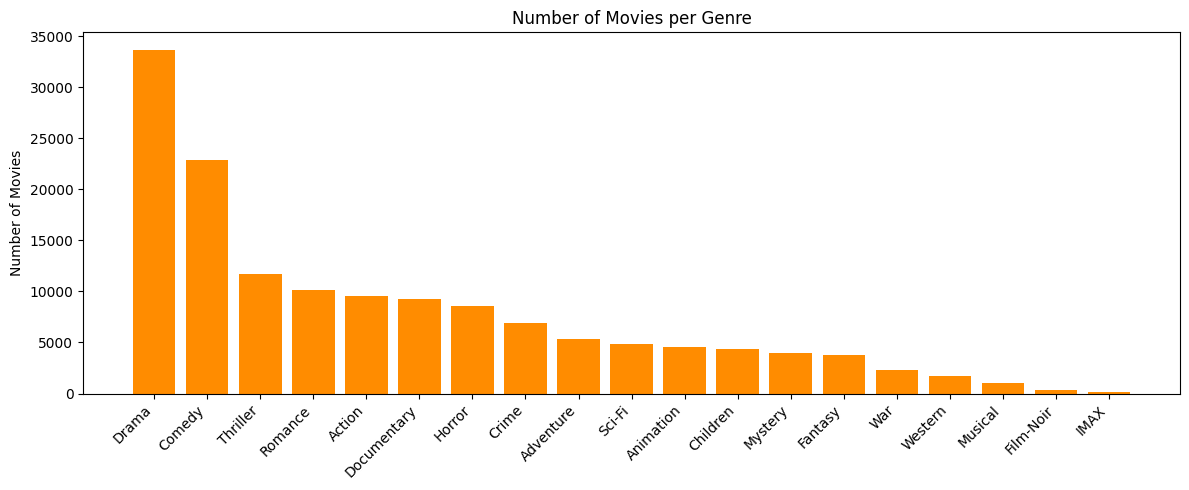

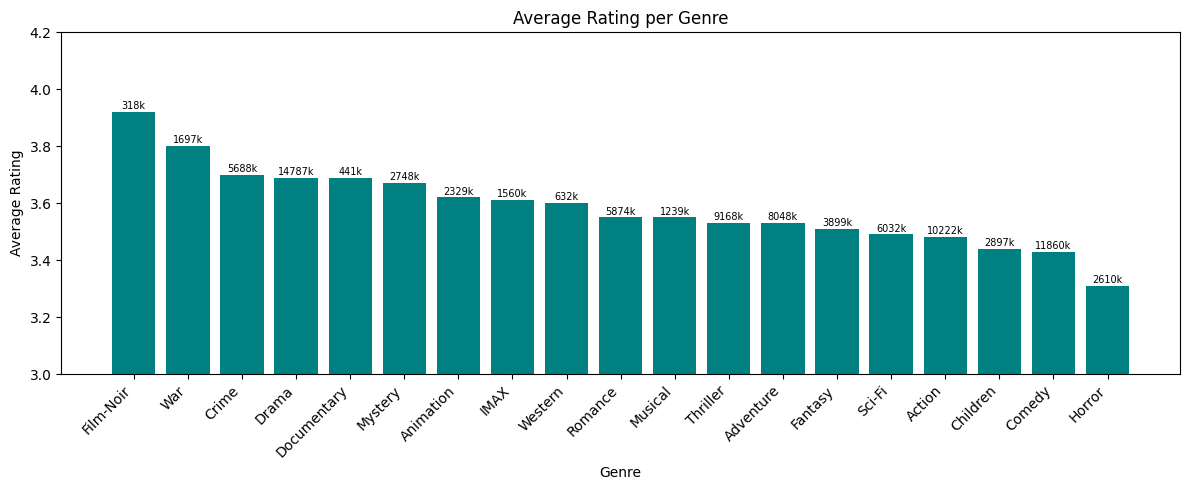

In [27]:
# Explode multi-genre column → count distinct genres, ratings per genre
# 6a — Distinct genres
genres_exploded = (movies_df
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .filter(col("genre") != "(no genres listed)")
)

distinct_genres = genres_exploded.select("genre").distinct().orderBy("genre")
print(f"\n=== Distinct Genres ({distinct_genres.count()} total) ===")
distinct_genres.show(30, truncate=False)

# 6b — Number of movies per genre
movies_per_genre = (genres_exploded
    .groupBy("genre")
    .agg(count("movieId").alias("num_movies"))
    .orderBy(desc("num_movies"))
    .toPandas()
)

plt.figure(figsize=(12, 5))
plt.bar(movies_per_genre["genre"], movies_per_genre["num_movies"], color="darkorange")
plt.xticks(rotation=45, ha="right")
plt.title("Number of Movies per Genre")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

# 6c — Average rating per genre (join with ratings)
genre_ratings = (movies_ratings_merged
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .filter(col("genre") != "(no genres listed)")
    .groupBy("genre")
    .agg(
        round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("num_ratings")
    )
    .orderBy(desc("avg_rating"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(genre_ratings["genre"], genre_ratings["avg_rating"], color="teal")
ax.set_ylim(3, 4.2)
ax.set_xlabel("Genre")
ax.set_ylabel("Average Rating")
ax.set_title("Average Rating per Genre")
plt.xticks(rotation=45, ha="right")
for bar, n in zip(bars, genre_ratings["num_ratings"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{n//1000}k", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

## Part 6: Number of ratings per user

+--------------------+-----------+
|avg_ratings_per_user|avg_rounded|
+--------------------+-----------+
|  102.21968728755948|     102.22|
+--------------------+-----------+



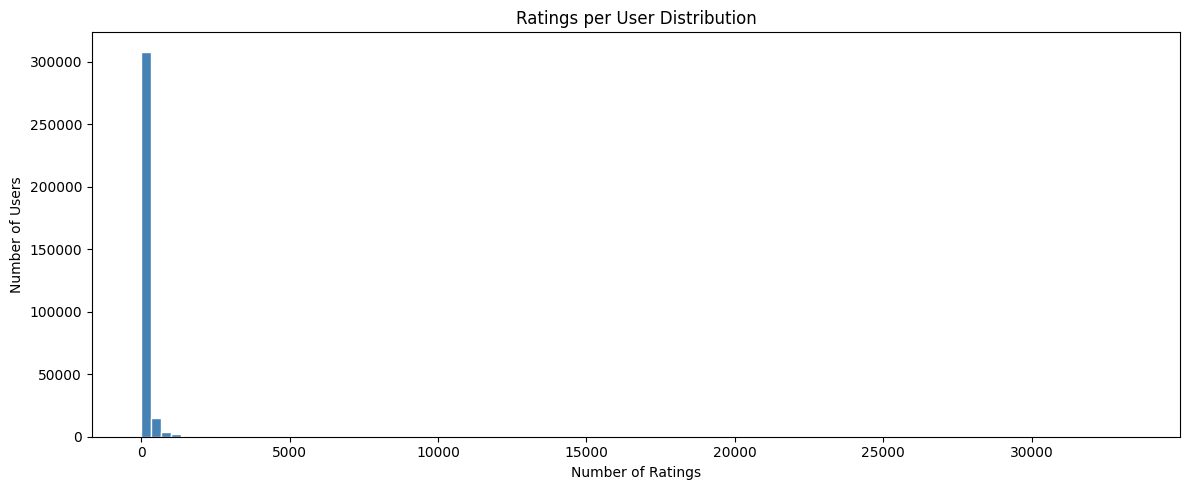

In [28]:
# Ratings per User
from pyspark.sql.functions import count, avg, round

# Count how many ratings each user has given
ratings_per_user = movies_ratings_merged.groupBy("userId") \
                                        .agg(count("rating").alias("num_ratings")) \
                                        .orderBy("num_ratings", ascending=False)

# Summary statistics
ratings_per_user.select(
    avg("num_ratings").alias("avg_ratings_per_user"),
    round(avg("num_ratings"), 2).alias("avg_rounded")
).show()

# Distribution — how many users gave X ratings
ratings_per_user_pd = ratings_per_user.toPandas()

plt.figure(figsize=(12, 5))
plt.hist(ratings_per_user_pd["num_ratings"], bins=100, color="steelblue", edgecolor="white")
plt.title("Ratings per User Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

### Observations:
 - The distribution is heavily right-skewed: the vast majority of users have rated
   fewer than 500 movies, while a small number of power users have rated thousands.
 - The average number of ratings per user is ~102, but this is pulled up by outliers.
 - This indicates that most users are casual raters, while a small group of highly
   active users dominates the total rating volume.

## Part 7: Top 10 most active users (based on number of ratings)

+------+-----------+----------+
|userId|num_ratings|avg_rating|
+------+-----------+----------+
|189614|      33332|      3.08|
| 48766|       9554|      2.57|
|207216|       9178|      3.28|
|175998|       9016|      3.18|
| 76618|       8919|      2.54|
|230765|       7719|      3.41|
|184775|       7535|      2.82|
|236260|       7488|      3.21|
|233891|       7372|      2.64|
|214831|       7266|      1.55|
+------+-----------+----------+



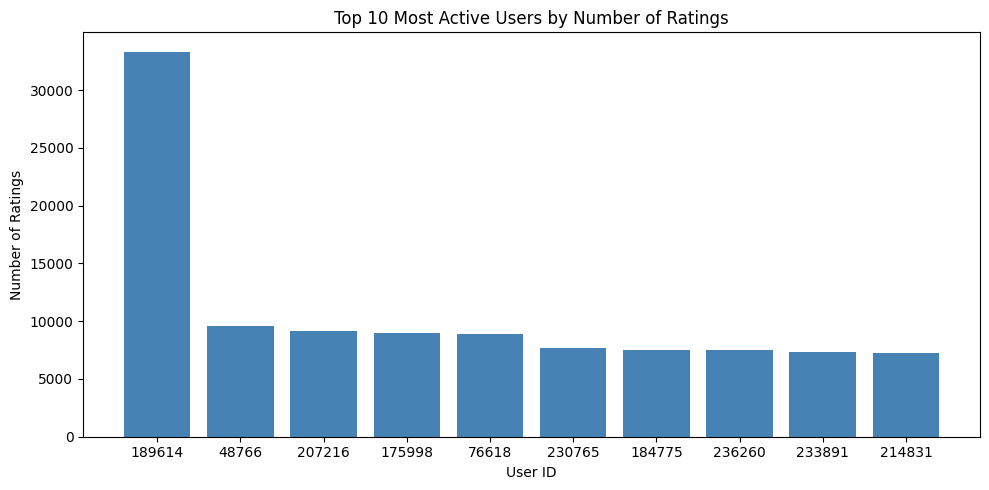

In [29]:
# ---- 4. Top 10 Most Active Users ----
from pyspark.sql.functions import col

# Get top 10 users by number of ratings given
top10_users = movies_ratings_merged.groupBy("userId") \
                                   .agg(count("rating").alias("num_ratings"),
                                        round(avg("rating"), 2).alias("avg_rating")) \
                                   .orderBy("num_ratings", ascending=False) \
                                   .limit(10)

top10_users.show()

# Plot top 10 most active users
top10_pd = top10_users.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(top10_pd["userId"].astype(str), top10_pd["num_ratings"], color="steelblue")
plt.title("Top 10 Most Active Users by Number of Ratings")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

#### User 189614 is by far the most active, with over 33,000 ratings — nearly 4x   more than the second most active user (48766 with ~9,500). Most top 10 users have average ratings between 2.5 and 3.5, suggesting that highly active users tend to be more critical than the average user. User 214831 stands out with an average rating of only 1.55 — extremely harsh critic.

### Favourite Genres of the top 10 users

In [30]:
from pyspark.sql.functions import explode, split

# Get the list of top 10 user IDs
top10_ids = [row["userId"] for row in top10_users.collect()]

# Filter merged df for only top 10 users, explode genres to get one per row,
# then count how many times each user rated each genre
top10_genres = movies_ratings_merged.filter(col("userId").isin(top10_ids)) \
    .withColumn("genre", explode(split(col("genres"), "\\|"))) \
    .groupBy("userId", "genre") \
    .agg(count("rating").alias("genre_count")) \
    .orderBy("userId", "genre_count", ascending=[True, False])

# For each user keep only their top 3 favorite genres
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

window = Window.partitionBy("userId").orderBy(col("genre_count").desc())

top10_fav_genres = top10_genres.withColumn("rank", rank().over(window)) \
                               .filter(col("rank") <= 3)

top10_fav_genres.show(30, truncate=False)

+------+--------+-----------+----+
|userId|genre   |genre_count|rank|
+------+--------+-----------+----+
|48766 |Drama   |5364       |1   |
|48766 |Thriller|2935       |2   |
|48766 |Comedy  |2650       |3   |
|76618 |Drama   |3459       |1   |
|76618 |Comedy  |2657       |2   |
|76618 |Thriller|1502       |3   |
|175998|Drama   |4725       |1   |
|175998|Comedy  |2231       |2   |
|175998|Thriller|1629       |3   |
|184775|Drama   |4443       |1   |
|184775|Thriller|1871       |2   |
|184775|Comedy  |1840       |3   |
|189614|Drama   |17000      |1   |
|189614|Comedy  |8169       |2   |
|189614|Thriller|4483       |3   |
|207216|Drama   |4834       |1   |
|207216|Comedy  |3271       |2   |
|207216|Romance |1850       |3   |
|214831|Comedy  |2968       |1   |
|214831|Drama   |2747       |2   |
|214831|Thriller|1619       |3   |
|230765|Drama   |3951       |1   |
|230765|Comedy  |2757       |2   |
|230765|Romance |1306       |3   |
|233891|Comedy  |2596       |1   |
|233891|Drama   |254

#### Drama is the #1 favorite genre for almost all top 10 users, which aligns with it being the most common genre in the dataset overall. Comedy and Thriller consistently appear as the 2nd and 3rd favorite genres, reflecting their large presence in the MovieLens catalog. No user has Action or Sci-Fi in their top 3, despite these being popular genres, suggesting that highly active users prefer character-driven over action-driven films.

## Number of Ratings vs Average Rating per Movie

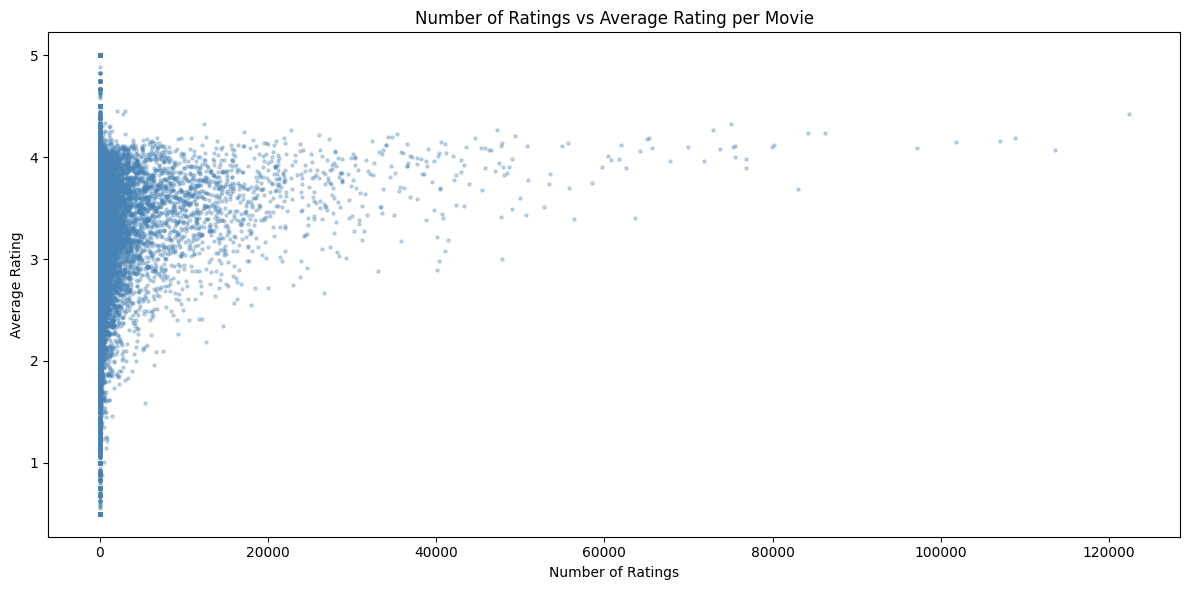

In [31]:
# Aggregate number of ratings and average rating per movie
movie_stats = movies_ratings_merged \
    .groupBy("movieId", "title") \
    .agg(count("rating").alias("num_ratings"),
         round(avg("rating"), 2).alias("avg_rating"))

movie_stats_pd = movie_stats.toPandas()

plt.figure(figsize=(12, 6))
plt.scatter(movie_stats_pd["num_ratings"],
            movie_stats_pd["avg_rating"],
            alpha=0.3, s=5, color="steelblue")

plt.title("Number of Ratings vs Average Rating per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()


#### Movies with very few ratings (left side of the plot) show extreme average ratings, spanning the full range from 0.5 to 5.0. With only a handful of ratings, there is not enough data to get a reliable estimate of the true quality - the average is highly sensitive to each individual opinion.
#### As the number of ratings increases, the average rating converges towards 3.5-4.0. This is known as the "regression to the mean" effect: with more ratings, the extreme values balance each other out and the average stabilizes towards the true quality of the movie.
#### The most rated movie (~122,000 ratings) maintains an average above 4.0, confirming that high popularity and high quality can go hand in hand.
#### We can conclude that the number of ratings is a key factor in the reliability of the average. A high avg_rating is only meaningful when supported by a large number of ratings.

## Average Rating per Genre per Decade

#### How ratings of older movies change over time

In [32]:
from pyspark.sql.functions import year, floor, to_timestamp

# Extract release decade from movie title
# Extract rating year directly from the ts column (already in datetime format)
rating_era = movies_ratings_merged \
    .withColumn("release_year", regexp_extract(col("title"), r"\((\d{4})\)", 1)) \
    .filter(col("release_year") != "") \
    .withColumn("release_year", col("release_year").cast("int")) \
    .withColumn("release_decade", (floor(col("release_year") / 10) * 10).cast("int")) \
    .filter((col("release_decade") >= 1960) & (col("release_decade") <= 1980)) \
    .withColumn("rating_year", year(to_timestamp(col("ts")))) \
    .withColumn("rating_decade", (floor(col("rating_year") / 10) * 10).cast("int")) \
    .groupBy("release_decade", "rating_decade") \
    .agg(round(avg("rating"), 2).alias("avg_rating"),
         count("rating").alias("num_ratings")) \
    .orderBy("release_decade", "rating_decade")

rating_era.show(30)

+--------------+-------------+----------+-----------+
|release_decade|rating_decade|avg_rating|num_ratings|
+--------------+-------------+----------+-----------+
|          1960|         1990|      3.91|     102926|
|          1960|         2000|      3.79|     479683|
|          1960|         2010|      3.75|     269194|
|          1960|         2020|      3.74|      81821|
|          1970|         1990|      3.86|     184855|
|          1970|         2000|      3.74|     814328|
|          1970|         2010|      3.79|     490136|
|          1970|         2020|      3.78|     153785|
|          1980|         1990|      3.63|     454975|
|          1980|         2000|      3.51|    2241632|
|          1980|         2010|      3.65|    1054750|
|          1980|         2020|      3.71|     302347|
+--------------+-------------+----------+-----------+



#### This analysis takes all movies released in the 1960s, 1970s and 1980s and tracks how their average rating changes depending on WHEN the rating was given.
#### Movies from the 1960s received their highest average rating in the 1990s (3.91), and show a gradual decline towards the 2020s (3.74). The num_ratings also drops from 479,683 in the 2000s to only 81,821 in the 2020s - meaning fewer and fewer people bother rating 1960s movies as time goes on.
#### Movies from the 1970s follow a similar pattern: highest in the 1990s (3.86), declining to 3.78 in the 2020s. The 2000s had the most ratings (814,328), suggesting that 1970s movies were most actively watched and rated in the 2000s.
#### Movies from the 1980s show a slight dip in the 2000s (3.51) but recover in the 2010s (3.65) and 2020s (3.71). This is interesting - 1980s movies seem to be appreciated more as time goes on, possibly due to nostalgia.
#### The declining num_ratings for older decades confirms that as time passes, fewer users engage with very old movies - only the most iconic ones still receive significant attention in the 2020s.

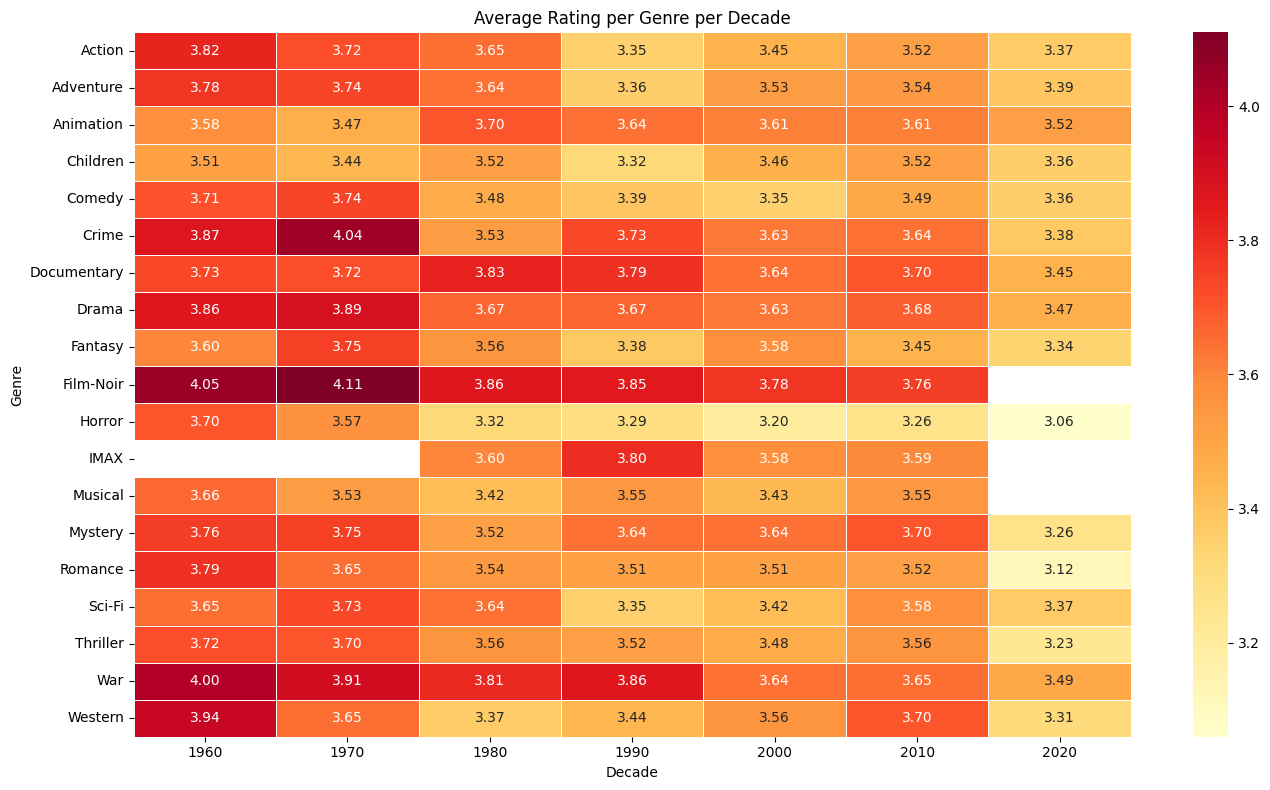

In [33]:
from pyspark.sql.functions import floor, regexp_extract

# Extract decade from release year (e.g. 1995 -> 1990s)
# Use try_cast instead of cast to handle empty strings gracefully (returns null instead of error)
genre_decade = movies_ratings_merged \
    .withColumn("release_year", regexp_extract(col("title"), r"\((\d{4})\)", 1)) \
    .filter(col("release_year") != "") \
    .withColumn("release_year", col("release_year").cast("int")) \
    .withColumn("decade", (floor(col("release_year") / 10) * 10).cast("int")) \
    .filter((col("decade") >= 1960) & (col("decade") <= 2020)) \
    .withColumn("genre", explode(split(col("genres"), "\\|"))) \
    .filter(col("genre") != "(no genres listed)") \
    .groupBy("decade", "genre") \
    .agg(round(avg("rating"), 2).alias("avg_rating"))

# Convert to pandas and pivot for heatmap format
genre_decade_pd = genre_decade.toPandas()
pivot = genre_decade_pd.pivot(index="genre", columns="decade", values="avg_rating")

import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Average Rating per Genre per Decade")
plt.xlabel("Decade")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

#### Film-Noir consistently receives the highest ratings across all decades until the 90s, peaking at 4.11 in the 70s - it is a niche but highly appreciated genre.
#### War movies were rated very highly in the 60s (4.00) but have declined steadily, reaching 3.49 in the 2020s.
#### Horror is the lowest rated genre overall and shows a consistent decline from 3.70 in the 60s down to 3.06 in the 2020s.
#### Almost all genres show a downward trend from the 60s-70s to the 2020s,this could be explained by two factors:
#####   1) Survivorship bias: only the best classic films from older decades exist in the dataset, while recent decades include all movies regardless of quality.
#####  2) Genuine quality decline: newer movies may simply be perceived as lower quality.
####   However, our separate analysis showed that even when tracking the SAME old movies over time, their ratings slightly decline as newer users rate them — suggesting that both factors contribute, and that newer users tend to judge older films more critically than earlier users did.
#### Crime had an unusually high rating in the 70s (4.04), likely due to iconic films like The Godfather dominating that decade.

## Genre Co-occurance Heatmap

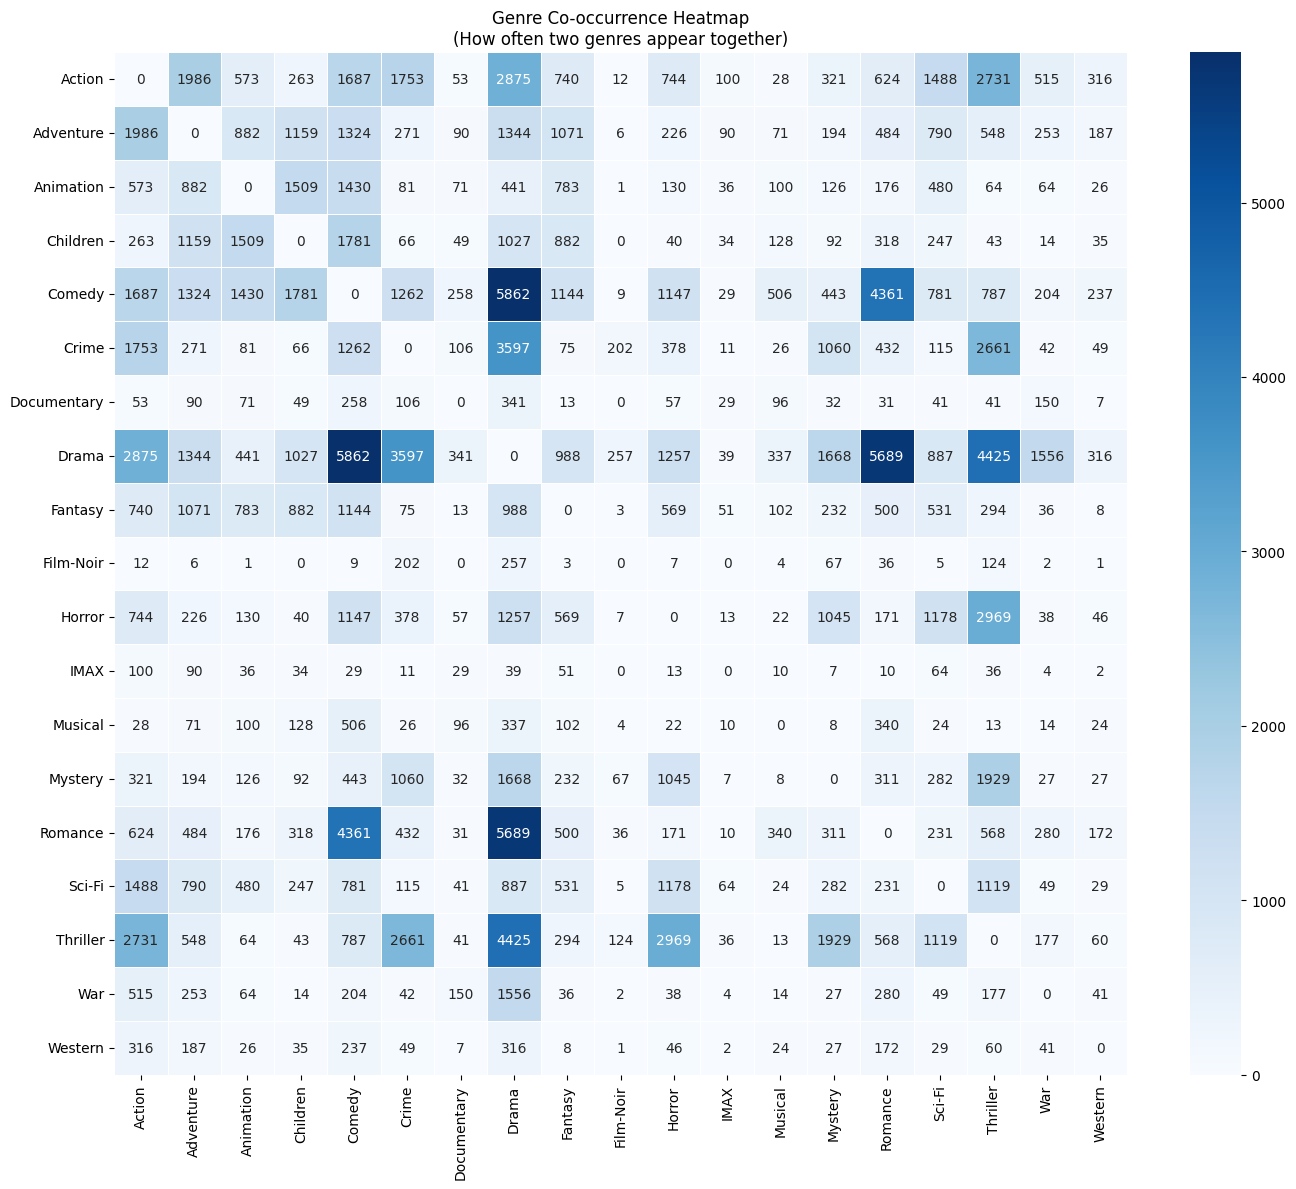

In [51]:
import numpy as np
# Get one row per genre per movie, excluding "(no genres listed)"
movie_genres = movies_ratings_merged \
    .select("movieId", "genres") \
    .distinct() \
    .withColumn("genre", explode(split(col("genres"), "\\|"))) \
    .filter(col("genre") != "(no genres listed)")

# Convert to pandas
movie_genres_pd = movie_genres.toPandas()

# Get unique genres
genres_list = sorted(movie_genres_pd["genre"].unique())

# Create empty co-occurrence matrix
cooc = pd.DataFrame(0, index=genres_list, columns=genres_list)

# For each movie, increment co-occurrence count for every genre pair
for movie_id, group in movie_genres_pd.groupby("movieId"):
    genres_in_movie = group["genre"].tolist()
    for g1 in genres_in_movie:
        for g2 in genres_in_movie:
            cooc.loc[g1, g2] += 1

# Set diagonal to 0 so self-co-occurrence doesn't dominate the colors
np.fill_diagonal(cooc.values, 0)

plt.figure(figsize=(14, 12))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Genre Co-occurrence Heatmap\n(How often two genres appear together)")
plt.tight_layout()
plt.show()

#### Drama is the most co-occurring genre overall. Its strongest pairs are with Comedy (5862) and Romance (5689), which are the two highest co-occurrence values in the entire matrix - reflecting how dominant Drama is as a base genre.
#### Comedy + Romance (4361) is a very strong pair, typical of romantic comedies.
#### Thriller + Drama (4425) and Thriller + Crime (2661) are also very common combinations, reflecting the typical crime-thriller genre blend.
#### Horror + Thriller (2969) is a notable pair, as the two genres naturally overlap.
#### Film-Noir, Documentary and IMAX have very low co-occurrences with other genres, indicating they tend to appear as standalone genres.
#### Action + Drama (2875) and Action + Thriller (2731) are the strongest action-based combinations, typical of blockbuster films.

# TMDB API

In this notebook, We use `links.csv` to connect each MovieLens `movieId` with its matching `tmdbId`. This is needed because the TMDB API uses `tmdbId` to find each movie.

After matching the IDs, I use the TMDB API to collect extra movie details such as **budget, runtime, director, and top-3 cast**. These new fields can then be joined back to the MovieLens ratings data for deeper analysis.

> **Prerequisites**
> - A free TMDB API key: https://www.themoviedb.org/settings/api
> - `links.csv` in the Google Drive project folder
> - `requests` installed, which is already available in Colab



In [52]:
# The API key must be replaced before running any TMDB request.
TMDB_API_KEY = "55d206bac9cdb44a8069f01785a51884"   # replace this with my TMDB API key

# This endpoint pulls movie details from TMDB.
# append_to_response=credits also brings cast and crew in the same request.
TMDB_BASE_URL = "https://api.themoviedb.org/3/movie/{tmdb_id}"
TMDB_PARAMS   = "?api_key={api_key}&append_to_response=credits"
TMDB_ENDPOINT = TMDB_BASE_URL + TMDB_PARAMS

# add a short delay between requests so the loop does not hit the TMDB rate limit.
REQUEST_DELAY_SECONDS = 0.26

print("Configuration set.")
print(f"  Endpoint  : {TMDB_ENDPOINT[:60]}...")
print(f"  Delay     : {REQUEST_DELAY_SECONDS}s between requests")


Configuration set.
  Endpoint  : https://api.themoviedb.org/3/movie/{tmdb_id}?api_key={api_ke...
  Delay     : 0.26s between requests


In [47]:
links_df = spark.read.csv(
    google_drive_path + "links.csv",
    header=True,
    inferSchema=True
)

print("links.csv schema:")
links_df.printSchema()

print(f"Total rows : {links_df.count()}")
print()

from pyspark.sql.functions import col, sum as spark_sum

# Movies without a tmdbId cannot be enriched, so check how many will be skipped.
null_tmdb = links_df.filter(col("tmdbId").isNull()).count()
print(f"Rows with null tmdbId: {null_tmdb}  (these will be skipped)")

links_df.show(5)


links.csv schema:
root
 |-- movieId: integer (nullable = true)
 |-- imdbId: integer (nullable = true)
 |-- tmdbId: integer (nullable = true)

Total rows : 86537

Rows with null tmdbId: 126  (these will be skipped)
+-------+------+------+
|movieId|imdbId|tmdbId|
+-------+------+------+
|      1|114709|   862|
|      2|113497|  8844|
|      3|113228| 15602|
|      4|114885| 31357|
|      5|113041| 11862|
+-------+------+------+
only showing top 5 rows


In [48]:
# Keep only movies that appear in my ratings data.
# This avoids wasting API calls on movies that are not part of the final analysis.
rated_movie_ids = set(
    row["movieId"]
    for row in movies_ratings_merged.select("movieId").distinct().collect()
)

print(f"Unique rated movieIds : {len(rated_movie_ids):,}")

# remove rows with missing or invalid TMDB IDs before starting the API loop.
links_filtered = (
    links_df
    .filter(col("movieId").isin(rated_movie_ids))
    .filter(col("tmdbId").isNotNull())
    .filter(col("tmdbId") > 0)
)

print(f"Movies to enrich      : {links_filtered.count():,}")


links_pd = links_filtered.select("movieId", "tmdbId").toPandas()
links_pd.head()


Unique rated movieIds : 83,238
Movies to enrich      : 83,115


,movieId,tmdbId
0,1,862
1,2,8844
2,3,15602
3,4,31357
4,5,11862


In [49]:
# Function for pulling one movie from TMDB.
# use one function so the API request, error handling, and field extraction stay organized.
import requests
import time

def fetch_tmdb_metadata(tmdb_id: int, api_key: str) -> dict:
    """
    Fetch TMDB details for one movie and return the fields I want to use later.
    If the request fails or the movie is missing, the function returns None.
    """
    url = TMDB_ENDPOINT.format(tmdb_id=tmdb_id, api_key=api_key)

    try:
        response = requests.get(url, timeout=10)

        # A 404 means TMDB does not have this movie page anymore, so skip it.
        if response.status_code == 404:
            return None

        # If TMDB is slow, wait and try the same movie one more time.
        if response.status_code == 429:
            print(f"  [rate limit] waiting 10s before retrying tmdbId={tmdb_id}")
            time.sleep(10)
            response = requests.get(url, timeout=10)

        response.raise_for_status()
        data = response.json()

        # The director is stored inside the crew list, so look for the crew member with job='Director'.
        crew = data.get("credits", {}).get("crew", [])
        directors = [p["name"] for p in crew if p.get("job") == "Director"]
        director = directors[0] if directors else None

        # TMDB gives cast in billing order, so the first three names are the main cast.
        cast = data.get("credits", {}).get("cast", [])
        cast_top3 = ", ".join(p["name"] for p in cast[:3]) if cast else None

        # Empty release dates are changed to None so Spark treats them as missing values.
        release_date = data.get("release_date") or None

        return {
            "tmdb_id"           : tmdb_id,
            "budget"            : data.get("budget"),
            "revenue"           : data.get("revenue"),
            "runtime"           : data.get("runtime"),
            "release_date"      : release_date,
            "vote_average"      : data.get("vote_average"),
            "vote_count"        : data.get("vote_count"),
            "original_language" : data.get("original_language"),
            "tagline"           : data.get("tagline"),
            "director"          : director,
            "cast_top3"         : cast_top3,
        }

    except requests.RequestException as e:
        # print the problem but keep the loop running, since one failed movie should not stop everything.
        print(f"  [error] tmdbId={tmdb_id}: {e}")
        return None

print("fetch_tmdb_metadata() defined.")


fetch_tmdb_metadata() defined.


In [53]:
# Quick API check before running the full loop.
# use The Dark Knight because it is a known movie with a stable TMDB ID.
# This confirms that the API key works and that the returned fields look correct.
test = fetch_tmdb_metadata(155, TMDB_API_KEY)
print("Smoke-test result (The Dark Knight):")
for k, v in test.items():
    print(f"  {k:<20}: {v}")


Smoke-test result (The Dark Knight):
  tmdb_id             : 155
  budget              : 185000000
  revenue             : 1004558444
  runtime             : 152
  release_date        : 2008-07-16
  vote_average        : 8.528
  vote_count          : 35568
  original_language   : en
  tagline             : Welcome to a world without rules.
  director            : Christopher Nolan
  cast_top3           : Christian Bale, Heath Ledger, Aaron Eckhart


In [ ]:
# Main enrichment loop
# This is the slowest part because it sends one API request per movie.
# WE use SAMPLE_SIZE for testing before running the full dataset.
import time

SAMPLE_SIZE = None    # try 500 for testing, then use None for the full run

run_df = links_pd if SAMPLE_SIZE is None else links_pd.head(SAMPLE_SIZE)
total = len(run_df)

print(f"Starting enrichment loop for {total:,} movies...")
print(f"Estimated time: ~{total * REQUEST_DELAY_SECONDS / 3600:.1f} hours")
print()

# results stores the TMDB fields, id_map keeps the MovieLens ID, and failed_ids tracks skipped movies.
results = []
id_map = {}
failed_ids = []

for i, row in enumerate(run_df.itertuples(index=False), start=1):
    movie_id = row.movieId
    tmdb_id = row.tmdbId

    id_map[int(tmdb_id)] = int(movie_id)

    metadata = fetch_tmdb_metadata(int(tmdb_id), TMDB_API_KEY)

    if metadata:
        results.append(metadata)
    else:
        failed_ids.append(tmdb_id)

    # Printing progress every 1000 movies helps track a long-running Colab job.
    if i % 1000 == 0:
        pct = 100 * i / total
        print(f"  [{i:,}/{total:,}]  {pct:.1f}%  fetched={len(results):,}  failed={len(failed_ids):,}")

    time.sleep(REQUEST_DELAY_SECONDS)

print()
print(f"Done. Fetched: {len(results):,}  |  Failed/skipped: {len(failed_ids):,}")


Starting enrichment loop for 83,115 movies...
Estimated time: ~6.0 hours

  [1,000/83,115]  1.2%  fetched=999  failed=1
  [2,000/83,115]  2.4%  fetched=1,999  failed=1


In [ ]:
# Turn the API results into a Pandas DataFrame.
# This makes the collected dictionaries easier to inspect and clean before moving back to Spark.
import pandas as pd

tmdb_pd = pd.DataFrame(results)

# Add MovieLens movieId back into the table so it can join with the rating data later.
tmdb_pd["movieId"] = tmdb_pd["tmdb_id"].map(id_map)

# TMDB uses 0 when budget, revenue, or runtime is unknown.
# Replace those values with missing values so averages and summaries are not misleading.
tmdb_pd["budget"]  = tmdb_pd["budget"].replace(0, pd.NA)
tmdb_pd["revenue"] = tmdb_pd["revenue"].replace(0, pd.NA)
tmdb_pd["runtime"] = tmdb_pd["runtime"].replace(0, pd.NA)

print(f"Shape: {tmdb_pd.shape}")
print()
print("Null counts per column:")
print(tmdb_pd.isnull().sum())
print()
tmdb_pd.head()


In [ ]:
# Convert the metadata into Spark so it can be joined back to the main data.
# Define the schema so Spark reads each column with the right data type.
from pyspark.sql.types import (
    StructType, StructField, IntegerType, LongType, DoubleType, StringType, DateType
)

tmdb_schema = StructType([
    StructField("movieId",            IntegerType(), nullable=True),
    StructField("tmdb_id",            IntegerType(), nullable=True),
    StructField("budget",             LongType(),    nullable=True),
    StructField("revenue",            LongType(),    nullable=True),
    StructField("runtime",            IntegerType(), nullable=True),
    StructField("release_date",       StringType(),  nullable=True),
    StructField("vote_average",       DoubleType(),  nullable=True),
    StructField("vote_count",         IntegerType(), nullable=True),
    StructField("original_language",  StringType(),  nullable=True),
    StructField("tagline",            StringType(),  nullable=True),
    StructField("director",           StringType(),  nullable=True),
    StructField("cast_top3",          StringType(),  nullable=True),
])

tmdb_spark = spark.createDataFrame(tmdb_pd, schema=tmdb_schema)

from pyspark.sql.functions import to_date, year as spark_year

# Convert release_date from text into a real Spark date, then create release_year for easier grouping.
tmdb_spark = (
    tmdb_spark
    .withColumn("release_date", to_date(col("release_date"), "yyyy-MM-dd"))
    .withColumn("release_year", spark_year(col("release_date")).cast("int"))
)


tmdb_spark.persist()

print(f"Rows in tmdb_spark: {tmdb_spark.count():,}")
tmdb_spark.printSchema()
tmdb_spark.show(5, truncate=False)


In [ ]:
# Join TMDB fields back to the ratings data.
enriched_df = movies_ratings_merged.join(
    tmdb_spark.select(
        "movieId", "budget", "revenue", "runtime",
        "release_date", "release_year",
        "vote_average", "director", "cast_top3", "original_language"
    ),
    on="movieId",
    how="left"
)

print(f"Rows in enriched_df : {enriched_df.count():,}")

# Preview a few important columns to make sure the join worked correctly.
enriched_df.select(
    "movieId", "title", "rating",
    "budget", "runtime", "release_date", "release_year", "director", "cast_top3"
).show(10, truncate=False)


In [ ]:
# Save the metadata so the API loop does not need to run again.
# This is useful because the full API loop can take several hours in Colab.
save_path = google_drive_path + "tmdb_metadata.csv"
tmdb_pd.to_csv(save_path, index=False)
print(f"Saved to: {save_path}")


In [ ]:
# Load saved TMDB metadata from a previous run.
# I can use this cell instead of running the long API loop again.
import pandas as pd

tmdb_pd = pd.read_csv(google_drive_path + "tmdb_metadata.csv")

# Re-clean these columns in case the saved CSV still contains 0 values from TMDB.
tmdb_pd["budget"]  = tmdb_pd["budget"].replace(0, pd.NA)
tmdb_pd["revenue"] = tmdb_pd["revenue"].replace(0, pd.NA)
tmdb_pd["runtime"] = tmdb_pd["runtime"].replace(0, pd.NA)

# Rebuild the Spark DataFrame so the rest of the notebook can continue normally.
tmdb_spark = spark.createDataFrame(tmdb_pd, schema=tmdb_schema)
tmdb_spark.persist()

print(f"Loaded {tmdb_spark.count():,} rows from cache.")


In [ ]:
## Example analyses with the TMDB data

Now `enriched_df` includes extra fields such as budget, runtime, director, cast, release date, and original language. These fields make it possible to ask more detailed questions, such as whether runtime affects ratings or which directors have the strongest average ratings in this dataset.


In [ ]:
# Top 10 directors by average rating.
# group by director and calculate the average user rating for each one.
# The filter keeps only directors with at least 3 movies so one movie does not dominate the result.
from pyspark.sql.functions import avg, count, round, desc

top_directors = (
    enriched_df
    .filter(col("director").isNotNull())
    .groupBy("director")
    .agg(
        round(avg("rating"), 3).alias("avg_rating"),
        count("movieId").alias("num_ratings"),
        count_distinct(col("movieId")).alias("num_movies")
    )
    .filter(col("num_movies") >= 3)
    .orderBy(desc("avg_rating"))
    .limit(10)
)

top_directors.show(truncate=False)


In [ ]:
# Average rating by runtime bucket.
from pyspark.sql.functions import floor

runtime_buckets = (
    enriched_df
    .filter(col("runtime").isNotNull() & (col("runtime") > 0))
    .withColumn("runtime_bucket", (floor(col("runtime") / 30) * 30).cast("int"))
    .groupBy("runtime_bucket")
    .agg(
        round(avg("rating"), 3).alias("avg_rating"),
        count("rating").alias("num_ratings")
    )
    .filter(col("num_ratings") >= 500)
    .orderBy("runtime_bucket")
    .toPandas()
)

import matplotlib.pyplot as plt

# The bar chart shows whether shorter or longer movies tend to receive different ratings.
plt.figure(figsize=(12, 5))
plt.bar(
    runtime_buckets["runtime_bucket"].astype(str) + "-" +
    (runtime_buckets["runtime_bucket"] + 30).astype(str),
    runtime_buckets["avg_rating"],
    color="steelblue"
)
plt.title("Average Rating by Runtime Bucket (minutes)")
plt.xlabel("Runtime Bucket (minutes)")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
